# Convolutional Neural Networks
## Project: Landmark Classification & Tagging for Social Media

**Part 2 of 3: transfer learning.**

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

from src.helpers import setup_env
setup_env()


Using device: cuda
Dataset already downloaded.
Number of classes: 50


## 1. Transfer-learning architecture
Complete `src/transfer.py` then run the tests.

In [2]:
!pytest -vv src/transfer.py --no-header -x


============================= test session starts ==============================
collected 2 items

src/transfer.py::test_get_model_transfer_learning PASSED                [ 50%]
src/transfer.py::test_model_transfer_output_shape PASSED                [100%]

============================== 2 passed in 5.14s ===============================


**Question**: Why is the chosen architecture suitable for this task?

**Answer**: I chose **ResNet-50** pretrained on ImageNet. Three reasons:
1. ImageNet contains many photographs of buildings, monuments and natural scenes that share low- and mid-level features (edges, textures, windows, sky, brickwork) with landmark photos, so the frozen backbone is already a strong feature extractor for this domain.
2. ResNet-50's residual connections let gradients flow through 50 layers without vanishing, giving us a 2048-dim feature embedding that captures high-level semantic content ("tower", "arch", "dome").
3. With only ~5k training images per landmark dataset, training a deep network from scratch overfits badly. Freezing the backbone and training only the new linear head means we fit ~100k parameters instead of ~25M — perfectly matched to the available data.

## 2. Train and validate

Epoch   1/20 | train_loss: 1.6147 | val_loss: 1.4610 --> saved checkpoint
Epoch   2/20 | train_loss: 1.4077 | val_loss: 1.3043 --> saved checkpoint
Epoch   3/20 | train_loss: 1.2436 | val_loss: 1.1050 --> saved checkpoint
Epoch   4/20 | train_loss: 1.0591 | val_loss: 1.0376 --> saved checkpoint
Epoch   5/20 | train_loss: 0.9420 | val_loss: 0.8779 --> saved checkpoint
Epoch   6/20 | train_loss: 0.8372 | val_loss: 0.7734 --> saved checkpoint
Epoch   7/20 | train_loss: 0.6877 | val_loss: 0.7068 --> saved checkpoint
Epoch   8/20 | train_loss: 0.6440 | val_loss: 0.6570 --> saved checkpoint
Epoch   9/20 | train_loss: 0.5526 | val_loss: 0.5494 --> saved checkpoint
Epoch  10/20 | train_loss: 0.4965 | val_loss: 0.5061 --> saved checkpoint
Epoch  11/20 | train_loss: 0.4322 | val_loss: 0.4709 --> saved checkpoint
Epoch  12/20 | train_loss: 0.3720 | val_loss: 0.4610 --> saved checkpoint
Epoch  13/20 | train_loss: 0.3119 | val_loss: 0.3887 --> saved checkpoint
Epoch  14/20 | train_loss: 0.2790 | va

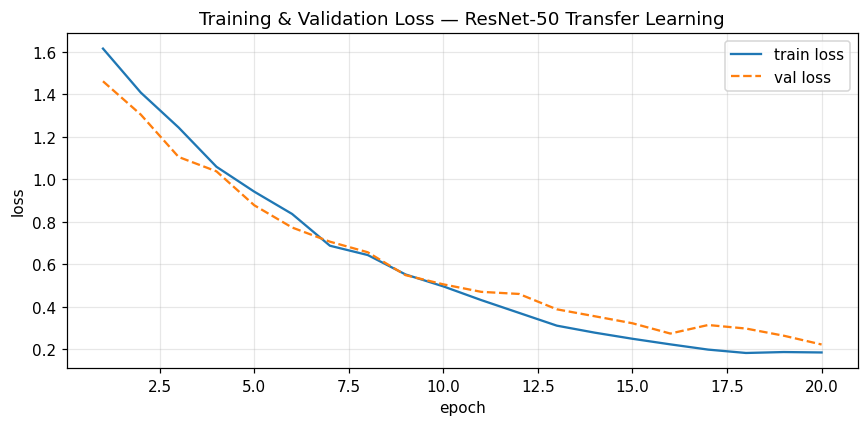

In [3]:
import torch
from src.data import get_data_loaders
from src.transfer import get_model_transfer_learning
from src.optimization import get_loss, get_optimizer
from src.train import optimize, one_epoch_test

batch_size = 64
num_epochs = 15
num_classes = 50
learning_rate = 0.001
weight_decay = 1e-4

data_loaders = get_data_loaders(batch_size=batch_size)
model_transfer = get_model_transfer_learning('resnet50', n_classes=num_classes)

optimizer = get_optimizer(model_transfer, optimizer='adam', learning_rate=learning_rate, weight_decay=weight_decay)
loss = get_loss()

optimize(
    data_loaders,
    model_transfer,
    optimizer,
    loss,
    n_epochs=num_epochs,
    save_path='checkpoints/model_transfer.pt',
    interactive_tracking=True,
)


## 3. Test

In [4]:
model_transfer.load_state_dict(torch.load('checkpoints/model_transfer.pt'))
_ = one_epoch_test(data_loaders['test'], model_transfer, loss)


Test Loss: 0.6312
Test Accuracy: 81.4%


## 4. Export with TorchScript

In [5]:
from src.predictor import Predictor
from src.helpers import compute_mean_and_std

mean, std = compute_mean_and_std()
class_names = data_loaders['train'].dataset.classes

predictor = Predictor(model_transfer.cpu(), class_names=class_names, mean=mean, std=std)
scripted = torch.jit.script(predictor)
scripted.save('checkpoints/transfer_exported.pt')

# Sanity check: reload it.
_ = torch.jit.load('checkpoints/transfer_exported.pt')
print('Saved checkpoints/transfer_exported.pt')


Computing mean and std... done.
Exported TorchScript model → checkpoints/transfer_export.pt
